# 3. Similarity Analysis

This notebook analyzes semantic similarity between political manifestos from the Archelec corpus.

The objective is to compare a lexical baseline based on TF-IDF with a semantic representation based on sentence embeddings.

The analysis includes:
- TF-IDF similarity
- embedding-based similarity
- document ranking
- qualitative comparison of retrieved documents
- heatmap visualization
- PCA projection
- similarity score distribution

In [ ]:
import os
import re
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

## 3.1 Upload and extract dataset

The dataset is uploaded as a zip file and extracted in the Colab environment.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving legislatives (1).zip to legislatives (1).zip


In [ ]:
zip_path = "/content/legislatives (1).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Extraction completed.")

Extraction completed.


In [ ]:
os.listdir("/content")

['.config', 'legislatives (1).zip', 'text_files', 'sample_data']

## 3.2 Loading the manifestos

Each manifesto is stored as a `.txt` file.  
We load all documents into a pandas DataFrame with two columns:

- `id`: file name
- `text`: manifesto content

In [ ]:
folder = "/content/text_files/1988/legislatives"

data = []

for filename in os.listdir(folder):
    if filename.endswith(".txt"):
        file_path = os.path.join(folder, filename)

        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()

        data.append({
            "id": filename,
            "text": text
        })

df = pd.DataFrame(data)

print("Number of documents:", len(df))
df.head()

Number of documents: 3628


,id,text
0,EL174_L_1988_06_003_01_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LÉGISLA...
1,EL175_L_1988_06_050_01_2_PF_01.txt,Michel ROCARD 1er Ministre\nvous demande d'app...
2,EL176_L_1988_06_056_06_1_PF_02.txt,Sciences Po / fonds CEVIPOF\nMajorité présiden...
3,EL175_L_1988_06_048_01_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANCA...
4,EL177_L_1988_06_088_03_2_PF_01.txt,Elections législatives du 12 Juin 1988 DÉPARTE...


## 3.3 Text preprocessing

The text is cleaned before computing vector representations.  
The cleaning step removes OCR noise, lowercases the text, removes non-alphabetic characters, and normalizes spacing.

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["id", "clean_text"]].head()

,id,clean_text
0,EL174_L_1988_06_003_01_1_PF_03.txt,sciences po fonds cevipof elections législativ...
1,EL175_L_1988_06_050_01_2_PF_01.txt,michel rocard er ministre vous demande d appor...
2,EL176_L_1988_06_056_06_1_PF_02.txt,sciences po fonds cevipof majorité présidentie...
3,EL175_L_1988_06_048_01_1_PF_03.txt,sciences po fonds cevipof republique francaise...
4,EL177_L_1988_06_088_03_2_PF_01.txt,elections législatives du juin département des...


## 3.4 Sampling

Computing embeddings and pairwise similarities for the full corpus can be computationally expensive.  
For this notebook, we use a random sample of documents.

This keeps the analysis efficient while still allowing us to observe meaningful similarity patterns.

In [ ]:
sample_size = 500

df_sample = df.sample(n=sample_size, random_state=42).reset_index(drop=True)

print("Sample size:", len(df_sample))
df_sample.head()

Sample size: 500


,id,text,clean_text
0,EL176_L_1988_06_057_06_1_PF_01.txt,Sciences Po / fonds CEVIPOF\nPOUR RASSEMBLER L...,sciences po fonds cevipof pour rassembler les ...
1,EL177_L_1988_06_083_07_1_PF_01.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,sciences po fonds cevipof elections legislativ...
2,EL174_L_1988_06_025_01_1_PF_05.txt,République Française\n1 ère circonscription\nD...,république française ère circonscription dépar...
3,EL176_L_1988_06_059_13_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nEMMANUEL DEWEES\n...,sciences po fonds cevipof emmanuel dewees cons...
4,EL175_L_1988_06_041_01_2_PF_02.txt,"Le 12 juin, VOTONS FRANCOIS BURDEYRON\nENSEMBL...",le juin votons francois burdeyron ensemble gag...


## 3.5 TF-IDF baseline

TF-IDF is used as a lexical baseline.  
It represents documents according to word frequency and term specificity.

This method captures lexical overlap but does not directly model semantic meaning.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.9
)

tfidf_matrix = vectorizer.fit_transform(df_sample["clean_text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (500, 7847)


In [ ]:
tfidf_sim = cosine_similarity(tfidf_matrix)

print("TF-IDF similarity matrix shape:", tfidf_sim.shape)

TF-IDF similarity matrix shape: (500, 500)


## 3.6 Sentence embeddings

We compute dense semantic representations using a pretrained Sentence Transformer model.

Unlike TF-IDF, sentence embeddings capture semantic relationships between texts, even when documents do not share the same vocabulary.

In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = df_sample["clean_text"].tolist()

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32
)

print("Embeddings shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embeddings shape: (500, 384)


## 3.7 Embedding-based cosine similarity

We compute cosine similarity between document embeddings.

This produces a matrix where each entry represents the semantic proximity between two manifestos.

In [ ]:
emb_sim = cosine_similarity(embeddings)

print("Embedding similarity matrix shape:", emb_sim.shape)

Embedding similarity matrix shape: (500, 500)


## 3.8 Similarity heatmap

The heatmap provides a global view of semantic relationships between documents.  
Brighter areas indicate higher similarity.

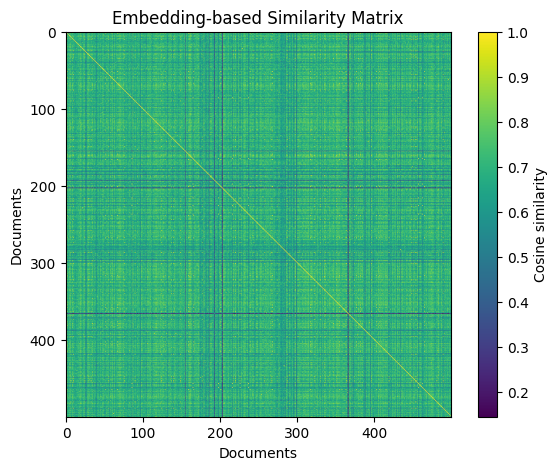

In [ ]:
plt.figure(figsize=(7, 5))
plt.imshow(emb_sim, cmap="viridis")
plt.colorbar(label="Cosine similarity")
plt.title("Embedding-based Similarity Matrix")
plt.xlabel("Documents")
plt.ylabel("Documents")
plt.show()

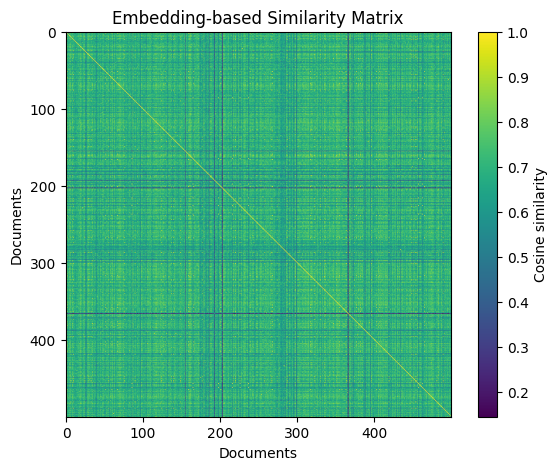

In [ ]:
plt.figure(figsize=(7, 5))
plt.imshow(emb_sim, cmap="viridis")
plt.colorbar(label="Cosine similarity")
plt.title("Embedding-based Similarity Matrix")
plt.xlabel("Documents")
plt.ylabel("Documents")
plt.savefig("similarity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.9 Document ranking task

We formulate similarity analysis as a ranking task.

Given a query manifesto, we retrieve the top-k most similar documents according to cosine similarity.

In [ ]:
def get_top_k(sim_matrix, query_idx, k=3):
    scores = sim_matrix[query_idx]
    top_indices = scores.argsort()[::-1][1:k+1]  # exclude the query document itself
    return top_indices

In [ ]:
query_idx = 0
top_k = 3

top_embedding_docs = get_top_k(emb_sim, query_idx, k=top_k)

print("Query document ID:")
print(df_sample.iloc[query_idx]["id"])

print("\nTop similar documents using embeddings:")
for rank, idx in enumerate(top_embedding_docs, start=1):
    print(f"{rank}. {df_sample.iloc[idx]['id']} | similarity = {emb_sim[query_idx, idx]:.4f}")

Query document ID:
EL176_L_1988_06_057_06_1_PF_01.txt

Top similar documents using embeddings:
1. EL177_L_1988_06_077_06_1_PF_03.txt | similarity = 0.8545
2. EL174_L_1988_06_014_01_1_PF_04.txt | similarity = 0.8530
3. EL176_L_1988_06_064_03_1_PF_01.txt | similarity = 0.8420


In [ ]:
top_tfidf_docs = get_top_k(tfidf_sim, query_idx, k=top_k)

print("Query document ID:")
print(df_sample.iloc[query_idx]["id"])

print("\nTop similar documents using TF-IDF:")
for rank, idx in enumerate(top_tfidf_docs, start=1):
    print(f"{rank}. {df_sample.iloc[idx]['id']} | similarity = {tfidf_sim[query_idx, idx]:.4f}")

Query document ID:
EL176_L_1988_06_057_06_1_PF_01.txt

Top similar documents using TF-IDF:
1. EL176_L_1988_06_057_05_1_PF_01.txt | similarity = 0.6585
2. EL176_L_1988_06_068_05_1_PF_04.txt | similarity = 0.5941
3. EL176_L_1988_06_067_05_1_PF_03.txt | similarity = 0.5770


## 3.10 Qualitative inspection of retrieved documents

We inspect the query document and its nearest neighbors to evaluate whether the retrieved documents are semantically coherent.

The text previews are limited to keep the notebook readable and PDF-friendly.

In [ ]:
def preview(text, n=800):
    return text[:n] + "..."

In [ ]:
print("QUERY DOCUMENT")
print("=" * 80)
print(preview(df_sample.iloc[query_idx]["text"], 800))

print("\n\nTOP EMBEDDING MATCH")
print("=" * 80)
print(preview(df_sample.iloc[top_embedding_docs[0]]["text"], 800))

print("\n\nTOP TF-IDF MATCH")
print("=" * 80)
print(preview(df_sample.iloc[top_tfidf_docs[0]]["text"], 800))

QUERY DOCUMENT
Sciences Po / fonds CEVIPOF
POUR RASSEMBLER LES FORCES DE GAUCHE
DANIEL BARTKOWIAK CONSEILLER REGIONAL DE LORRAINE
JUSTICE LIBERTÉ PAIX
JEAN-CLAUDE SCHMIDT MAIRE ADJOINT DE BEHREN-LES-FORBACH
CANDIDATS PRÉSENTÉS PAR LE PARTI COMMUNISTE FRANÇAIS
Vu le candidat
ÉLECTIONS LÉGISLATIVES - 6e CIRCONSCRIPTION - 5-12 JUIN 1988Madame, Mademoiselle, Monsieur,
Je suis, comme une majorité d'entre vous, pro- fondément attaché aux valeurs de gauche, celles de justice sociale, de liberté et de paix. Elles constituent la base de mon engagement politi- que. Comme vous, je sais aussi que l'élection présidentielle et ces élections législatives préci- pitées ne régleront aucun des grands problèmes auxquels vous êtes confrontés.
Notre Bassin Houiller Lorrain est menacé et la perspective de «l'Europe 1992» aggr...


TOP EMBEDDING MATCH
DÉPARTEMENT DE SEINE-ET-MARNE
ÉLECTIONS LÉGISLATIVES
RÉPUBLIQUE FRANÇAISE
6e CIRCONSCRIPTION
Scrutin du 5 juin 1988
POUR LE RASSEMBLEMENT DES FORCES DE GAUCHE


In [ ]:
print("TOP EMBEDDING MATCHES")
print("=" * 80)

for rank, idx in enumerate(top_embedding_docs, start=1):
    print(f"\n--- Rank {rank}: {df_sample.iloc[idx]['id']} ---")
    print(preview(df_sample.iloc[idx]["text"], 500))

TOP EMBEDDING MATCHES

--- Rank 1: EL177_L_1988_06_077_06_1_PF_03.txt ---
DÉPARTEMENT DE SEINE-ET-MARNE
ÉLECTIONS LÉGISLATIVES
RÉPUBLIQUE FRANÇAISE
6e CIRCONSCRIPTION
Scrutin du 5 juin 1988
POUR LE RASSEMBLEMENT DES FORCES DE GAUCHE
JEAN-PIERRE BONTOUX
ATTACHÉ PARLEMENTAIRE
Sciences Po / fonds CEVIPOF
SUPPLÉANT : NOËL FRABOULET MAIRE DE MITRY-MORY CONSEILLER GÉNÉRAL
CANDIDATS PRÉSENTÉS PAR LE PARTI COMMUNISTE FRANÇAIS
Madame, Monsieur,
Je me présente à vos suffrages animé par deux raisons qui n'ont cessé de guider mes activités dans notre région durant ces dernières a...

--- Rank 2: EL174_L_1988_06_014_01_1_PF_04.txt ---
Sciences Po / fonds CEVIPOF
Jane TILLARD
CANDIDATE DE RASSEMBLEMENT DES FORCES DE GAUCHE
PRÉSENTÉE PAR LE PARTI COMMUNISTE FRANÇAIS
Suppléant : Eugène VRAC
Maire adjoint de Louvigny
Maire de Fleury-sur-orne
Élections Législatives des 5 et 12 juin 1988Sciences Po / fonds CEVIPOF
Madame, Monsieur,
P our barrer la route du pouvoir à la droite et à l'extrême droite, comme

## 3.11 Comparing TF-IDF and embeddings

We compare the top documents retrieved by TF-IDF and by embeddings.

TF-IDF retrieves documents based on lexical overlap, while embeddings retrieve documents based on semantic proximity.

In [ ]:
print("TF-IDF top documents:")
for rank, idx in enumerate(top_tfidf_docs, start=1):
    print(f"{rank}. {df_sample.iloc[idx]['id']}")

print("\nEmbedding top documents:")
for rank, idx in enumerate(top_embedding_docs, start=1):
    print(f"{rank}. {df_sample.iloc[idx]['id']}")

TF-IDF top documents:
1. EL176_L_1988_06_057_05_1_PF_01.txt
2. EL176_L_1988_06_068_05_1_PF_04.txt
3. EL176_L_1988_06_067_05_1_PF_03.txt

Embedding top documents:
1. EL177_L_1988_06_077_06_1_PF_03.txt
2. EL174_L_1988_06_014_01_1_PF_04.txt
3. EL176_L_1988_06_064_03_1_PF_01.txt


In [ ]:
tfidf_set = set(top_tfidf_docs)
embedding_set = set(top_embedding_docs)

overlap = tfidf_set.intersection(embedding_set)

print("Number of overlapping documents in top-k:", len(overlap))
print("Overlap ratio:", len(overlap) / top_k)

Number of overlapping documents in top-k: 0
Overlap ratio: 0.0


## 3.12 Interpretation of model comparison

A low overlap between TF-IDF and embedding rankings suggests that the two methods capture different types of similarity.

TF-IDF mainly captures shared vocabulary, while embeddings capture broader semantic relationships.

This supports the use of embeddings for political manifesto analysis, where similar ideas may be expressed with different words.

## 3.13 PCA visualization

To visualize the embedding space, we project document embeddings into two dimensions using PCA.

This allows us to inspect whether documents form visible groups in semantic space.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(embeddings)

df_sample["pca_1"] = pca_result[:, 0]
df_sample["pca_2"] = pca_result[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.07073304 0.06624849]


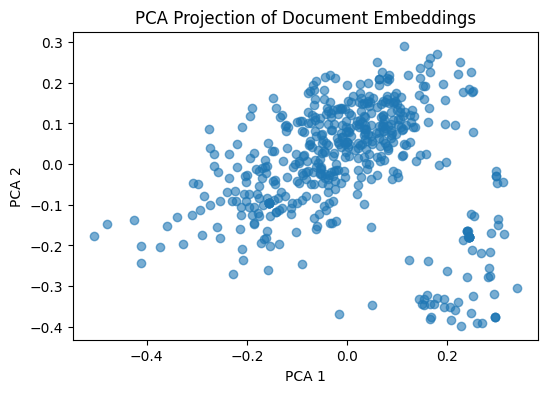

In [ ]:
import matplotlib.pyplot as plt
plt.show()

print("\n\n")
plt.rcParams.update({'figure.max_open_warning': 0})
plt.figure(figsize=(6,4))
plt.scatter(df_sample["pca_1"], df_sample["pca_2"], alpha=0.6)
plt.title("PCA Projection of Document Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

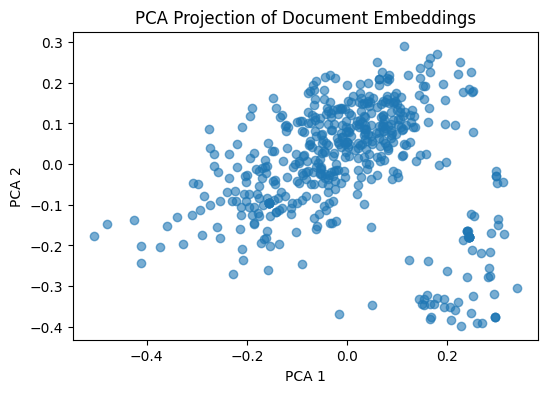

In [ ]:
import matplotlib.pyplot as plt
plt.show()

print("\n\n")
plt.rcParams.update({'figure.max_open_warning': 0})
plt.figure(figsize=(6,4))
plt.scatter(df_sample["pca_1"], df_sample["pca_2"], alpha=0.6)
plt.title("PCA Projection of Document Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.savefig("pca_embeddings.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.14 Similarity score distribution

We inspect the distribution of pairwise embedding similarity scores.

This helps determine whether most documents are generally close to each other or whether similarity is concentrated among specific groups.

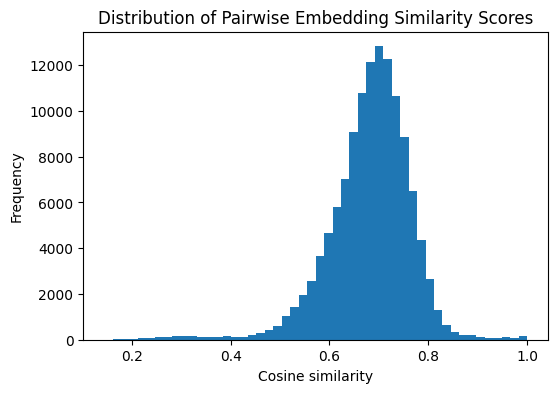

In [ ]:
sim_values = emb_sim[np.triu_indices_from(emb_sim, k=1)]

import matplotlib.pyplot as plt
plt.show()

print("\n\n")
plt.rcParams.update({'figure.max_open_warning': 0})
plt.figure(figsize=(6,4))
plt.hist(sim_values, bins=50)
plt.title("Distribution of Pairwise Embedding Similarity Scores")
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.show()

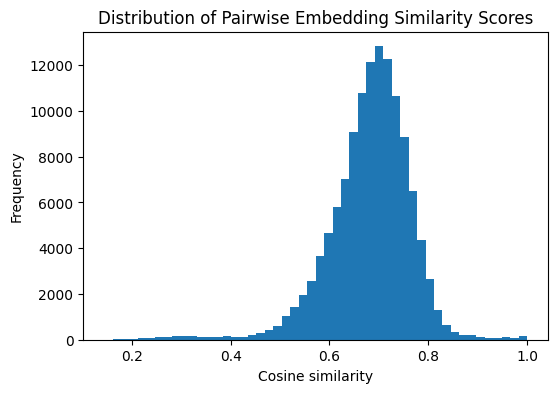

In [ ]:
import matplotlib.pyplot as plt
plt.show()

print("\n\n")
plt.rcParams.update({'figure.max_open_warning': 0})
plt.figure(figsize=(6,4))
plt.hist(sim_values, bins=50)
plt.title("Distribution of Pairwise Embedding Similarity Scores")
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.savefig("similarity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.15 Summary

This notebook compared lexical and semantic similarity methods.

The TF-IDF baseline captures similarity based on shared vocabulary, while embeddings capture broader semantic proximity between documents.

The ranking task shows how embeddings can retrieve contextually related manifestos, and the PCA visualization suggests structure in the embedding space.

These results motivate the use of transformer-based embeddings for analyzing political discourse.